## Transcript data details 
Transcripts and audios were redacted for privacy reasons

In [68]:
import pandas as pd

df=pd.read_csv('data.csv')
print(df.shape)

print("words in first row:", len(df.iloc[0]['text'].split()))

df.head(10)

(61504, 1)
words in first row: 644


,text
0,Please press [PHONE_NUMBER] to discuss an appo...
1,Thank you for calling [ORGANIZATION] [ORGANIZA...
2,Good afternoon. Thank you for calling [ORGANIZ...
3,"Thank you for calling [ORGANIZATION], a forefr..."
4,"[ORGANIZATION] [ORGANIZATION] [ORGANIZATION], ..."
5,"Hello, this is [PERSON_NAME] [PERSON_NAME], [O..."
6,Thank you for calling [ORGANIZATION] [ORGANIZA...
7,Thank you for calling [ORGANIZATION] [ORGANIZA...
8,Thank you for calling [ORGANIZATION] [ORGANIZA...
9,Thank you for calling [ORGANIZATION] [ORGANIZA...


### Words in a particular transcript

# Using pre-trained BERT
 To generate embeddings of transcripts 

In [70]:
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import BertTokenizer, BertModel,AutoTokenizer, AutoModel

# ============================================================
# CONFIGURATION
# ============================================================

INPUT_CSV = "data.csv"
OUTPUT_CSV = "embeddings.csv"
SAMPLED_TEXTS_CSV = "sampled_transcripts.csv"  # Added output path for transcripts

TEXT_COLUMN = "text"

NUM_TRANSCRIPTS = 500      # None -> Process entire dataset

RANDOM_SEED = 42

MAX_LENGTH = 512            # BERT maximum
CHUNK_SIZE = 510            # 510 + CLS + SEP = 512

BATCH_SIZE = 64           # Increase if GPU has more VRAM

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(INPUT_CSV)

if NUM_TRANSCRIPTS is not None:
    df = (
        df.sample(
            n=min(NUM_TRANSCRIPTS, len(df)),
            random_state=RANDOM_SEED
        )
        .reset_index(drop=True)
    )

print(f"Transcripts selected : {len(df)}")

# ============================================================
# LOAD MODEL
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = BertModel.from_pretrained("bert-base-uncased")

# tokenizer = AutoTokenizer.from_pretrained(
#     "sentence-transformers/all-mpnet-base-v2"
# )

# model = AutoModel.from_pretrained(
#     "sentence-transformers/all-mpnet-base-v2"
# )

model.to(device)
model.eval()

# ============================================================
# BUILD ALL CHUNKS
# ============================================================

all_chunks = []
transcript_map = []

print("\nCreating chunks...")

for idx, text in tqdm(enumerate(df[TEXT_COLUMN]),
                      total=len(df)):

    text = str(text)

    tokens = tokenizer.encode(
        text,
        add_special_tokens=False
    )

    for i in range(0, len(tokens), CHUNK_SIZE):

        chunk = tokens[i:i + CHUNK_SIZE]

        chunk = (
            [tokenizer.cls_token_id]
            + chunk +
            [tokenizer.sep_token_id]
        )

        all_chunks.append(chunk)

        transcript_map.append(idx)

print(f"\nTotal chunks : {len(all_chunks)}")

# ============================================================
# GENERATE EMBEDDINGS
# ============================================================

chunk_embeddings = []

print("\nGenerating chunk embeddings...")

for start in tqdm(
    range(0, len(all_chunks), BATCH_SIZE)
):

    batch = all_chunks[start:start+BATCH_SIZE]

    encoding = tokenizer.pad(
        {"input_ids": batch},
        padding=True,
        return_tensors="pt"
    )

    encoding = {
        k: v.to(device)
        for k, v in encoding.items()
    }

    with torch.no_grad():

        outputs = model(**encoding)

        # Mean Pooling over tokens
        embeddings = outputs.last_hidden_state.mean(dim=1)

    chunk_embeddings.extend(
        embeddings.cpu().numpy()
    )

# ============================================================
# COMBINE CHUNKS OF SAME TRANSCRIPT
# ============================================================

print("\nCombining chunks...")

transcript_embeddings = [[] for _ in range(len(df))]

for emb, transcript_idx in zip(
    chunk_embeddings,
    transcript_map
):

    transcript_embeddings[transcript_idx].append(emb)

final_embeddings = []

for emb_list in transcript_embeddings:

    emb = np.mean(
        emb_list,
        axis=0
    )

    final_embeddings.append(emb)

# ============================================================
# SAVE
# ============================================================

embedding_df = pd.DataFrame(final_embeddings)

embedding_df.to_csv(
    OUTPUT_CSV,
    index=False
)

# Save the sampled text transcripts in the exact corresponding order
df[[TEXT_COLUMN]].to_csv(
    SAMPLED_TEXTS_CSV,
    index=False
)

print("\n====================================")
print("Finished Successfully!")
print("====================================")
print("Embeddings Shape    :", embedding_df.shape)
print("Saved Embeddings to :", OUTPUT_CSV)
print("Saved Transcripts to:", SAMPLED_TEXTS_CSV)

Transcripts selected : 500
Device : cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Creating chunks...


100%|██████████| 500/500 [00:00<00:00, 568.39it/s]



Total chunks : 1287

Generating chunk embeddings...


100%|██████████| 21/21 [00:27<00:00,  1.31s/it]



Combining chunks...

Finished Successfully!
Embeddings Shape    : (500, 768)
Saved Embeddings to : embeddings.csv
Saved Transcripts to: sampled_transcripts.csv


### Using PCA

Original Shape: (500, 768)
Reduced Shape: (500, 2)

Explained Variance Ratio
PC1 : 0.1840
PC2 : 0.1048
Total : 0.2888


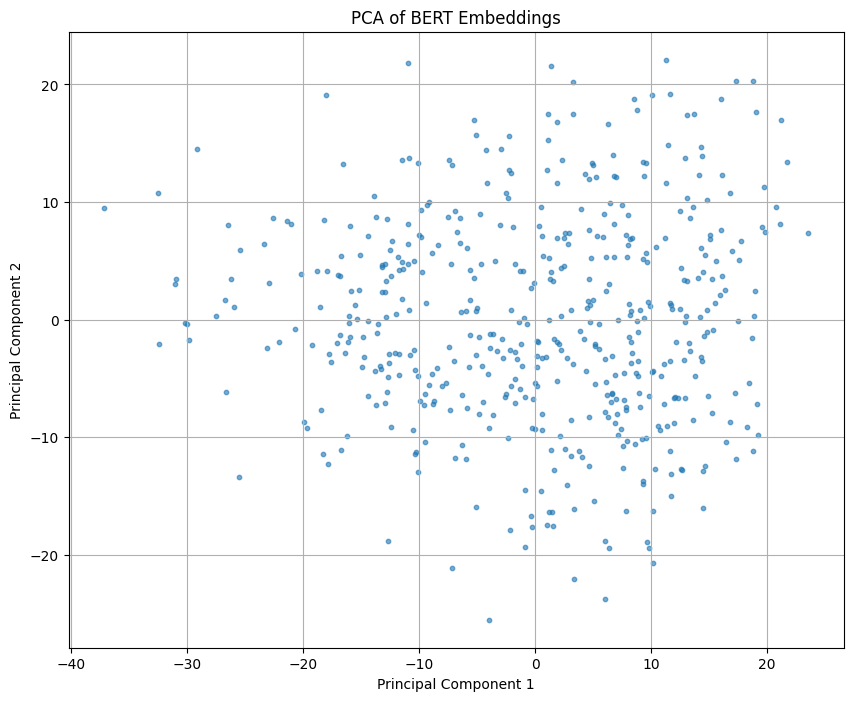

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =====================================
# Load Embeddings
# =====================================

embeddings = pd.read_csv("embeddings.csv")

print("Original Shape:", embeddings.shape)

# =====================================
# Standardize Features
# =====================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(embeddings)

# =====================================
# Apply PCA
# =====================================

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("Reduced Shape:", X_pca.shape)

# =====================================
# Explained Variance
# =====================================

print("\nExplained Variance Ratio")

print(f"PC1 : {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2 : {pca.explained_variance_ratio_[1]:.4f}")

print(
    f"Total : {sum(pca.explained_variance_ratio_):.4f}"
)

# =====================================
# Scatter Plot
# =====================================

plt.figure(figsize=(10,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    s=10,
    alpha=0.6
)

plt.title("PCA of BERT Embeddings")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

In [72]:
e=pd.read_csv('sampled_transcripts.csv')
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)
e_=pd.concat([e, pca_df], axis=1)

pca_df.to_csv("pca_embeddings.csv", index=False)

### UMAP

Original Shape: (500, 768)


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced Shape: (500, 2)


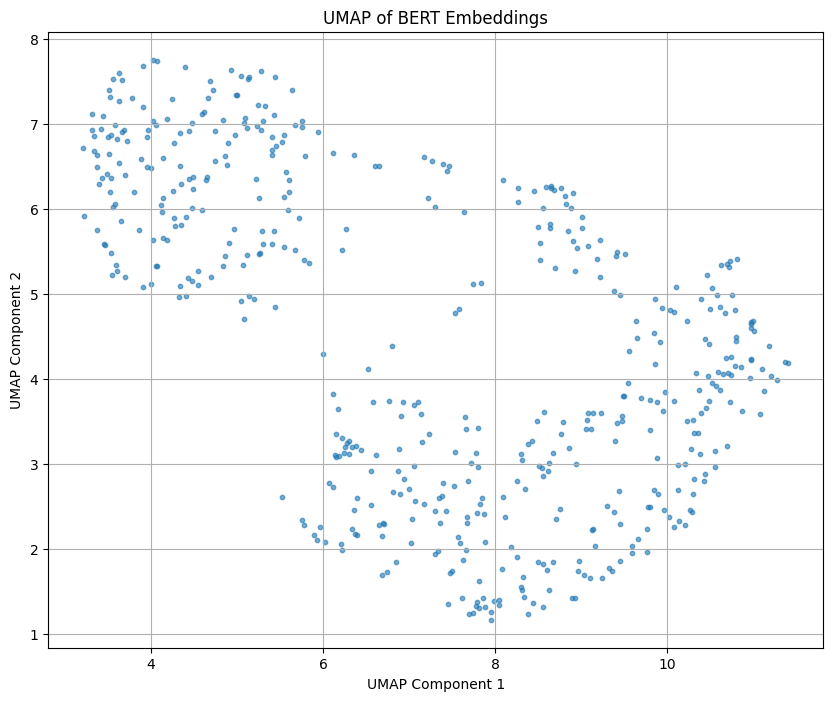

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap

# =====================================
# Load Embeddings
# =====================================

embeddings = pd.read_csv("embeddings.csv")

print("Original Shape:", embeddings.shape)

# =====================================
# Standardize
# =====================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(embeddings)

# =====================================
# UMAP
# =====================================

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

print("Reduced Shape:", X_umap.shape)

# =====================================
# Plot
# =====================================

plt.figure(figsize=(10,8))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    s=10,
    alpha=0.6
)

plt.title("UMAP of BERT Embeddings")

plt.xlabel("UMAP Component 1")

plt.ylabel("UMAP Component 2")

plt.grid(True)

plt.show()

In [74]:
umap_df = pd.DataFrame(
    X_umap,
    columns=["UMAP1", "UMAP2"]
)
e_2=pd.concat([e_, umap_df], axis=1)
umap_df.to_csv("umap_embeddings.csv", index=False)
e_2.to_csv("sampled_transcripts.csv", index=False)

## Isolation Forest


In [75]:
import pandas as pd
from sklearn.ensemble import IsolationForest

# Load embeddings
embeddings = pd.read_csv("embeddings.csv")

# Train Isolation Forest
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

iso.fit(embeddings)

# Predict BEFORE modifying the dataframe
predictions = iso.predict(embeddings)
scores = -iso.score_samples(embeddings)

# Now add the results
e=pd.read_csv('sampled_transcripts.csv')
e["iso_prediction"] = predictions
e["iso_score"] = scores


In [76]:
print(e["iso_prediction"].value_counts())

iso_prediction
 1    475
-1     25
Name: count, dtype: int64


## DBSCAN

In [77]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# ===================================
# Load Embeddings
# ===================================

embeddings = pd.read_csv("embeddings.csv")

# ===================================
# Standardize
# ===================================

scaler = StandardScaler()

X = scaler.fit_transform(embeddings)

# ===================================
# DBSCAN
# ===================================

dbscan = DBSCAN(
    eps=0.30,
    min_samples=5,
    metric="cosine",
    n_jobs=-1
)

clusters = dbscan.fit_predict(X)
print("Clusters found :", len(set(clusters)) - (1 if -1 in clusters else 0))

print("Noise points :", (clusters == -1).sum())

print("Noise % :", (clusters == -1).mean() * 100)

e["cluster"] = clusters

print(e["cluster"].value_counts())

Clusters found : 3
Noise points : 480
Noise % : 96.0
cluster
-1    480
 0      8
 1      7
 2      5
Name: count, dtype: int64


In [78]:
noise = embeddings[
    e["cluster"] == -1
]

print(noise.shape)

(480, 768)


In [79]:
e.to_csv("transcripts_dbscan_iso.csv", index=False)

print(e.head())

                                                text        PC1        PC2  \
0  Thank you for calling [ORGANIZATION] [ORGANIZA... -12.561415  -3.691705   
1  Good morning. Thank you for calling [ORGANIZAT...  -8.345634   6.383903   
2  Thank you for calling [ORGANIZATION] [ORGANIZA...   7.969416   6.310150   
3  Thank you for calling [ORGANIZATION] [ORGANIZA... -15.133659   2.511397   
4  Thank you for calling [ORGANIZATION] [ORGANIZA...   7.865535 -16.266718   

       UMAP1     UMAP2  iso_prediction  iso_score  cluster  
0   3.663593  6.900241               1   0.426641       -1  
1   5.751222  6.959803               1   0.408066       -1  
2  10.521956  3.952210               1   0.390072       -1  
3   5.281055  6.930761               1   0.416797       -1  
4   6.701042  2.301036               1   0.420998       -1  


In [80]:
top = e.sort_values(
    "iso_score",
    ascending=False
)

top[["text","iso_score","cluster"]].head(20)

,text,iso_score,cluster
322,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.589106,-1
412,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.585124,-1
43,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.576655,-1
300,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.561653,-1
135,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.553421,-1
113,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.546524,-1
35,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.522738,-1
442,Thank you for calling [PERSON_NAME]. [PERSON_N...,0.518824,-1
86,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.515767,-1
481,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.511690,-1


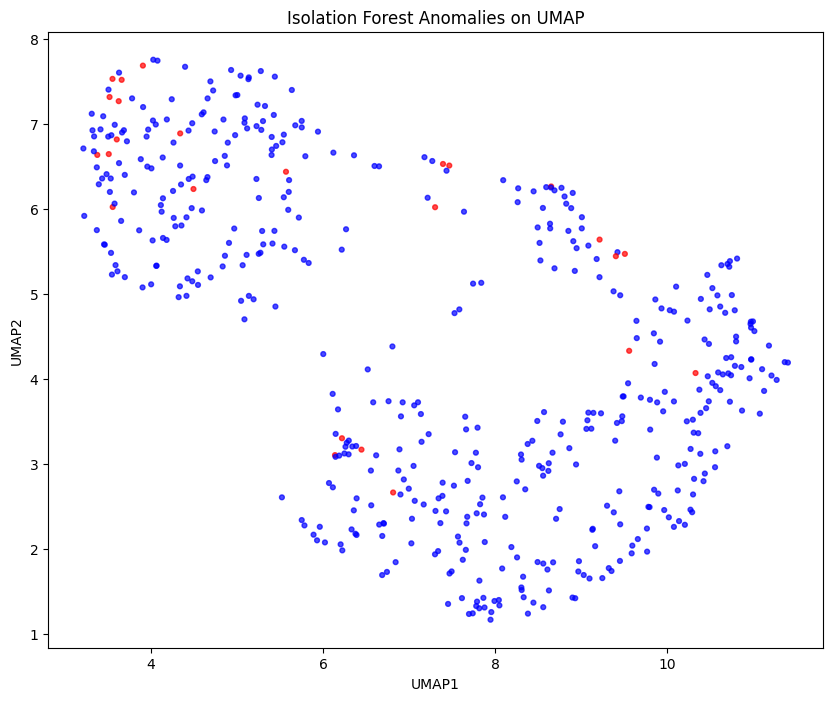

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

colors = e["iso_prediction"].map({
    1: "blue",
    -1: "red"
})

plt.scatter(
    e["UMAP1"],
    e["UMAP2"],
    c=colors,
    s=12,
    alpha=0.7
)

plt.title("Isolation Forest Anomalies on UMAP")

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.show()

### Sentiment analysis

In [82]:
import pandas as pd
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# =====================================
# Load your current dataframe
# =====================================

df = pd.read_csv("transcripts_dbscan_iso.csv")   # Change filename if needed

# =====================================
# Initialize VADER
# =====================================

analyzer = SentimentIntensityAnalyzer()

neg_scores = []
neu_scores = []
pos_scores = []
compound_scores = []

# =====================================
# Analyze Sentiment
# =====================================

for text in tqdm(df["text"], desc="Running VADER"):

    scores = analyzer.polarity_scores(str(text))

    neg_scores.append(scores["neg"])
    neu_scores.append(scores["neu"])
    pos_scores.append(scores["pos"])
    compound_scores.append(scores["compound"])

# =====================================
# Add to DataFrame
# =====================================

df["sent_neg"] = neg_scores
df["sent_neu"] = neu_scores
df["sent_pos"] = pos_scores
df["sent_compound"] = compound_scores

# =====================================
# Save
# =====================================



print("Done!")
print(df.head())

Running VADER: 100%|██████████| 500/500 [00:06<00:00, 72.33it/s] 

Done!
                                                text        PC1        PC2  \
0  Thank you for calling [ORGANIZATION] [ORGANIZA... -12.561415  -3.691705   
1  Good morning. Thank you for calling [ORGANIZAT...  -8.345634   6.383903   
2  Thank you for calling [ORGANIZATION] [ORGANIZA...   7.969416   6.310150   
3  Thank you for calling [ORGANIZATION] [ORGANIZA... -15.133659   2.511397   
4  Thank you for calling [ORGANIZATION] [ORGANIZA...   7.865535 -16.266718   

       UMAP1     UMAP2  iso_prediction  iso_score  cluster  sent_neg  \
0   3.663593  6.900241               1   0.426641       -1     0.021   
1   5.751222  6.959803               1   0.408066       -1     0.007   
2  10.521956  3.952210               1   0.390072       -1     0.015   
3   5.281055  6.930761               1   0.416797       -1     0.020   
4   6.701042  2.301036               1   0.420998       -1     0.033   

   sent_neu  sent_pos  sent_compound  
0     0.838     0.142         0.9984  
1     0.800   

### Risk Engine

In [83]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["iso_norm"] = scaler.fit_transform(df[["iso_score"]])

In [84]:
df["dbscan_outlier"] = (df["cluster"] == -1).astype(int)

In [85]:
ISO_WEIGHT = 70

DBSCAN_WEIGHT = 10

NEG_WEIGHT = 15

POS_WEIGHT = 5

In [86]:
df["risk_score"] = (

ISO_WEIGHT * df["iso_norm"]

+

DBSCAN_WEIGHT * df["dbscan_outlier"]

+

NEG_WEIGHT * df["sent_neg"]

-

POS_WEIGHT * df["sent_pos"]

)

In [87]:
df["risk_score"] = df["risk_score"].clip(0,100)

In [88]:
print(df["risk_score"].describe())

count    500.000000
mean      26.344521
std       10.680997
min        9.389072
25%       19.169062
50%       23.814336
75%       31.270627
max       79.220000
Name: risk_score, dtype: float64


In [89]:
def risk_level(score):

    if score >= 70:
        return "High"

    elif score >= 40:
        return "Medium"

    else:
        return "Low"

df["risk_level"] = df["risk_score"].apply(risk_level)

In [90]:
df["iso_contribution"] = ISO_WEIGHT * df["iso_norm"]
df["dbscan_contribution"] = DBSCAN_WEIGHT * df["dbscan_outlier"]
df["neg_contribution"] = NEG_WEIGHT * df["sent_neg"]
df["pos_contribution"] = -POS_WEIGHT * df["sent_pos"]

In [91]:
high_risk = df.sort_values(
    "risk_score",
    ascending=False
)

print(
    high_risk.head(20)
)

                                                  text        PC1        PC2  \
322  Thank you for calling [ORGANIZATION] [ORGANIZA... -29.166175  14.552518   
412  Thank you for calling [ORGANIZATION] [ORGANIZA... -37.176603   9.503785   
43   Thank you for calling [ORGANIZATION] [ORGANIZA... -32.536185  10.801754   
300  Thank you for calling [ORGANIZATION] [ORGANIZA...  19.524919   7.884381   
135  Thank you for calling [ORGANIZATION] [ORGANIZA...  19.245315  -9.803686   
113  Thank you for calling [ORGANIZATION] [ORGANIZA...  19.729186  11.298221   
35   Thank you for calling [ORGANIZATION] [ORGANIZA...  11.169325   6.926622   
442  Thank you for calling [PERSON_NAME]. [PERSON_N...  10.179628 -20.709840   
86   Thank you for calling [ORGANIZATION] [ORGANIZA...  -0.996668   4.098375   
356  Hi, thank you for calling [ORGANIZATION] [ORGA... -30.144777  -0.300730   
481  Thank you for calling [ORGANIZATION] [ORGANIZA...  13.066992  17.423595   
234  Hi, this is [PERSON_NAME], how can 

In [92]:
df.to_csv(
    "risk_engine_results.csv",
    index=False
)

print("Risk engine completed successfully!")

Risk engine completed successfully!


In [93]:
print(df["risk_level"].value_counts())

risk_level
Low       447
Medium     49
High        4
Name: count, dtype: int64


In [94]:
df.to_csv("final_results.csv", index=False)

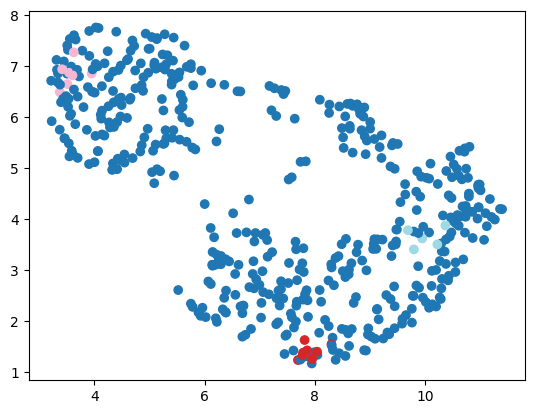

In [95]:
plt.scatter(
    e["UMAP1"],
    e["UMAP2"],
    c=e["cluster"],
    cmap="tab20"
)